# Marketing Funnel Analysis: Visitor → Lead → MQL → SQL → Customer

**Goal:** Identify where users drop off in the funnel, which channels bring high-quality leads,
and what actions would improve conversion.

**Dataset:** Simulated marketing funnel data (12,000 visitor journeys, Jan–Jun 2026) across
six channels (Organic Search, Paid Search, Social Media, Email, Referral, Direct). Simulated
data is used here since real GA/CRM exports weren't available, but the structure, cleaning
steps, and analysis mirror what you'd do on live Google Analytics + CRM data.

**Tools:** Python (pandas, matplotlib, seaborn) in Jupyter — chosen for exploratory analysis,
reproducible funnel metrics, and documented analytical logic.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

STAGES = ["Visitor", "Lead", "MQL", "SQL", "Customer"]


## 1. Load & Clean Data

Raw export has typical real-world issues: inconsistent casing, duplicate rows, and missing campaign tags.

In [2]:
df = pd.read_csv("data/funnel_raw.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (12120, 7)


,visitor_id,visit_date,channel,campaign,acquisition_cost,stage_reached,deal_value_usd
0,109106,2026-03-15,Email,Product Drip Campaign,8,SQL,0
1,108871,2026-05-24,Email,Newsletter,8,Customer,1837
2,100033,2026-04-15,Organic Search,SEO - Blog,0,Visitor,0
3,110427,2026-04-13,Direct,Direct/None,0,Visitor,0
4,108645,2026-04-11,Email,Newsletter,0,Visitor,0


In [3]:
before = len(df)
df = df.drop_duplicates(subset="visitor_id", keep="first")
df["channel"] = df["channel"].str.strip().str.title()
df["campaign"] = df["campaign"].fillna("Unknown / Untagged")
df["visit_date"] = pd.to_datetime(df["visit_date"])
df["stage_reached"] = pd.Categorical(df["stage_reached"], categories=STAGES, ordered=True)
after = len(df)

print(f"Removed {before - after} duplicate rows ({before} -> {after})")
print("Remaining nulls:\n", df.isna().sum())


Removed 120 duplicate rows (12120 -> 12000)
Remaining nulls:
 visitor_id          0
visit_date          0
channel             0
campaign            0
acquisition_cost    0
stage_reached       0
deal_value_usd      0
dtype: int64


## 2. Overall Funnel

Each visitor's `stage_reached` is their *furthest* stage. Since the funnel is nested (a Customer was also a Lead, MQL, and SQL), we compute cumulative counts per stage.

In [4]:
stage_rank = {s: i for i, s in enumerate(STAGES)}
df["stage_rank"] = df["stage_reached"].map(stage_rank)

cumulative = pd.Series({s: (df["stage_rank"] >= i).sum() for s, i in stage_rank.items()})
conv_from_prev = (cumulative / cumulative.shift(1)).fillna(1) * 100
conv_from_top = (cumulative / cumulative.iloc[0]) * 100

funnel_summary = pd.DataFrame({
    "count": cumulative,
    "pct_of_total_visitors": conv_from_top.round(1),
    "conv_from_prev_stage_pct": conv_from_prev.round(1),
})
funnel_summary


,count,pct_of_total_visitors,conv_from_prev_stage_pct
Visitor,12000,100.0,100.0
Lead,2358,19.7,19.7
MQL,1242,10.4,52.7
SQL,511,4.3,41.1
Customer,191,1.6,37.4


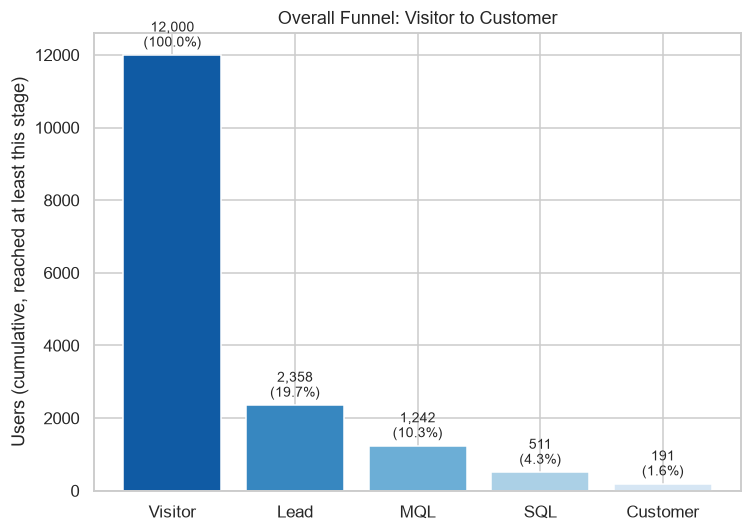

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(STAGES, cumulative.values, color=sns.color_palette("Blues_r", len(STAGES)))
for b, v, pct in zip(bars, cumulative.values, conv_from_top.values):
    ax.text(b.get_x() + b.get_width()/2, v + max(cumulative)*0.01, f"{v:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Overall Funnel: Visitor to Customer")
ax.set_ylabel("Users (cumulative, reached at least this stage)")
plt.tight_layout()
plt.show()


**Read:** the biggest single drop is **Visitor → Lead** (only ~19.7% of visitors ever become a
lead — this is where most of the 12,000 people are lost). The second-largest percentage drop is
**SQL → Customer** (~37% loss), meaning even sales-qualified leads aren't closing at a great rate.

## 3. Channel Performance

Which channels bring *volume* vs. which bring *quality* (leads that actually convert)?

In [6]:
channel_stats = []
for ch, g in df.groupby("channel"):
    visitors = len(g)
    leads = (g["stage_rank"] >= 1).sum()
    customers = (g["stage_rank"] == 4).sum()
    revenue = g.loc[g["stage_reached"] == "Customer", "deal_value_usd"].sum()
    cost = g["acquisition_cost"].sum()
    channel_stats.append({
        "channel": ch,
        "visitors": visitors,
        "leads": leads,
        "customers": customers,
        "visitor_to_lead_pct": round(leads / visitors * 100, 2) if visitors else 0,
        "lead_to_customer_pct": round(customers / leads * 100, 2) if leads else 0,
        "overall_conv_pct": round(customers / visitors * 100, 2) if visitors else 0,
        "revenue_usd": revenue,
        "spend_usd": cost,
        "roi_x": round(revenue / cost, 1) if cost else np.nan,
    })

channel_df = pd.DataFrame(channel_stats).sort_values("overall_conv_pct", ascending=False)
channel_df


,channel,visitors,leads,customers,visitor_to_lead_pct,lead_to_customer_pct,overall_conv_pct,revenue_usd,spend_usd,roi_x
4,Referral,1080,406,74,37.59,18.23,6.85,108337,2030,53.4
1,Email,1200,365,43,30.42,11.78,3.58,59854,2920,20.5
0,Direct,1800,333,21,18.50,6.31,1.17,29143,0,NaN
2,Organic Search,2880,453,33,15.73,7.28,1.15,41836,5436,7.7
3,Paid Search,2400,544,19,22.67,3.49,0.79,27301,26112,1.0
5,Social Media,2640,257,1,9.73,0.39,0.04,1006,8995,0.1


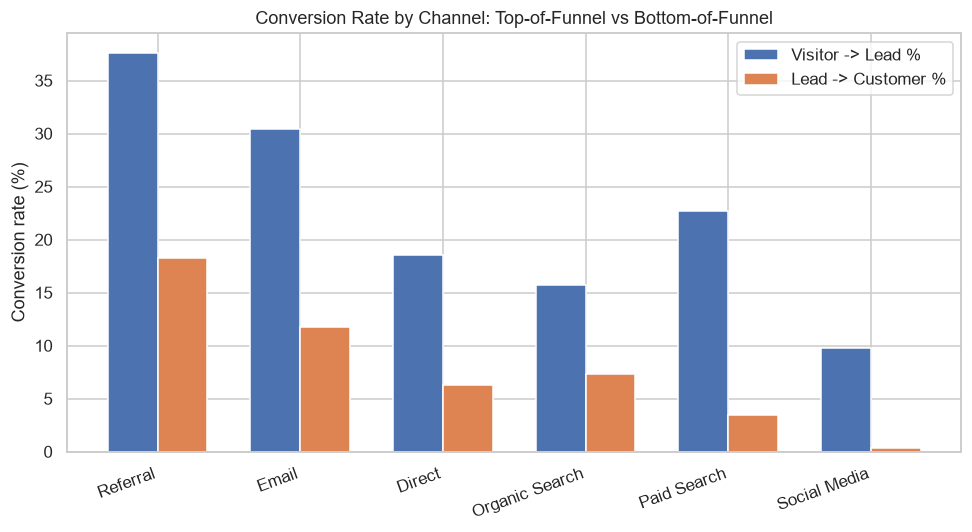

In [7]:
x = np.arange(len(channel_df))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, channel_df["visitor_to_lead_pct"], width=w, label="Visitor -> Lead %")
ax.bar(x + w/2, channel_df["lead_to_customer_pct"], width=w, label="Lead -> Customer %")
ax.set_xticks(x)
ax.set_xticklabels(channel_df["channel"], rotation=20, ha="right")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion Rate by Channel: Top-of-Funnel vs Bottom-of-Funnel")
ax.legend()
plt.tight_layout()
plt.show()


**Read:** Social Media pulls in decent traffic but both its top-of-funnel *and* bottom-of-funnel
rates are the weakest (0.39% lead→customer) — high volume, low quality. Referral and Email are the
opposite: lower volume, much higher quality at every stage.

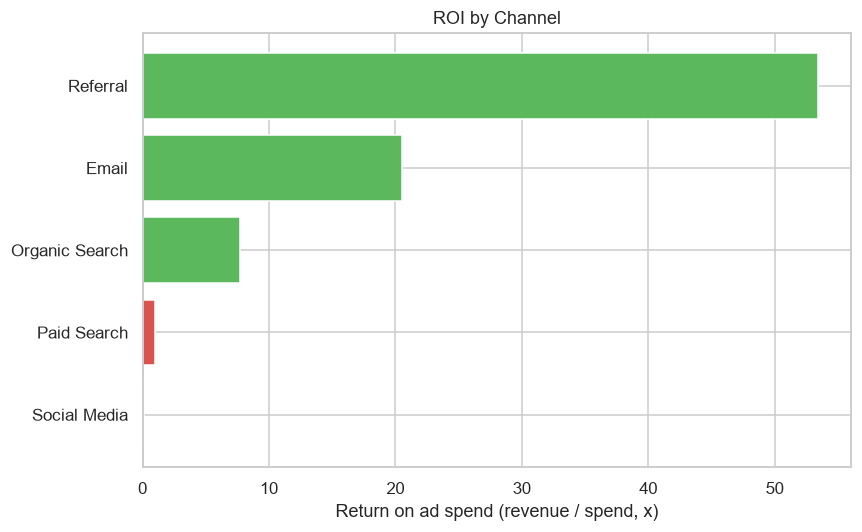

In [8]:
roi_df = channel_df.dropna(subset=["roi_x"]).sort_values("roi_x")
colors = ["#d9534f" if v < 5 else "#5cb85c" for v in roi_df["roi_x"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(roi_df["channel"], roi_df["roi_x"], color=colors)
ax.set_xlabel("Return on ad spend (revenue / spend, x)")
ax.set_title("ROI by Channel")
plt.tight_layout()
plt.show()


**Read:** Referral (53x) and Email (20x) return far more revenue per dollar spent than Paid Search
(1.0x, break-even) or Social Media (0.1x, losing money). Organic Search sits in the middle at 7.7x
(and has no direct media spend beyond content/SEO cost assumptions here).

## 4. Monthly Trend

Is the overall conversion rate improving or declining over time?

In [9]:
df["month"] = df["visit_date"].dt.to_period("M").astype(str)
monthly = df.groupby("month").agg(
    visitors=("visitor_id", "count"),
    leads=("stage_rank", lambda x: (x >= 1).sum()),
    customers=("stage_rank", lambda x: (x == 4).sum()),
).reset_index()
monthly["overall_conv_pct"] = (monthly["customers"] / monthly["visitors"] * 100).round(2)
monthly


,month,visitors,leads,customers,overall_conv_pct
0,2026-01,616,111,5,0.81
1,2026-02,1556,296,20,1.29
2,2026-03,2877,566,52,1.81
3,2026-04,3631,695,53,1.46
4,2026-05,2545,528,39,1.53
5,2026-06,775,162,22,2.84


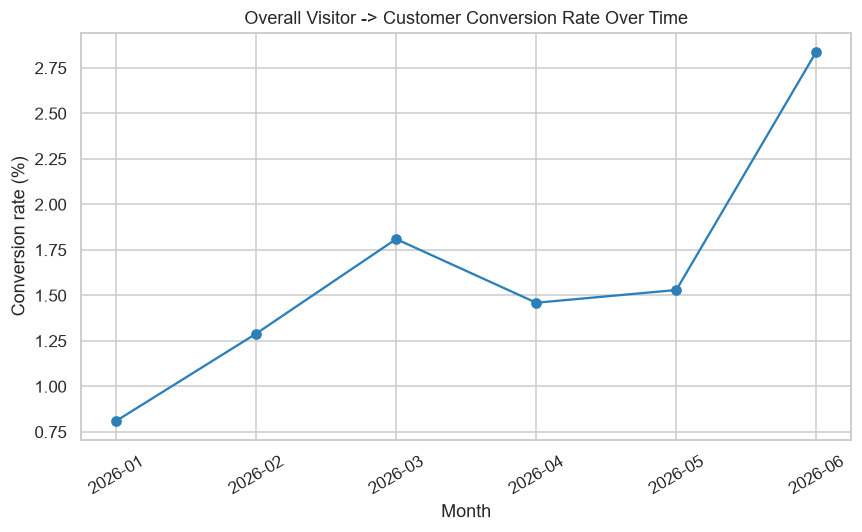

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(monthly["month"], monthly["overall_conv_pct"], marker="o", color="#2c7fb8")
ax.set_title("Overall Visitor -> Customer Conversion Rate Over Time")
ax.set_ylabel("Conversion rate (%)")
ax.set_xlabel("Month")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 5. Funnel Shape by Channel

Normalized (% of that channel's own visitors) so shapes are comparable regardless of volume.

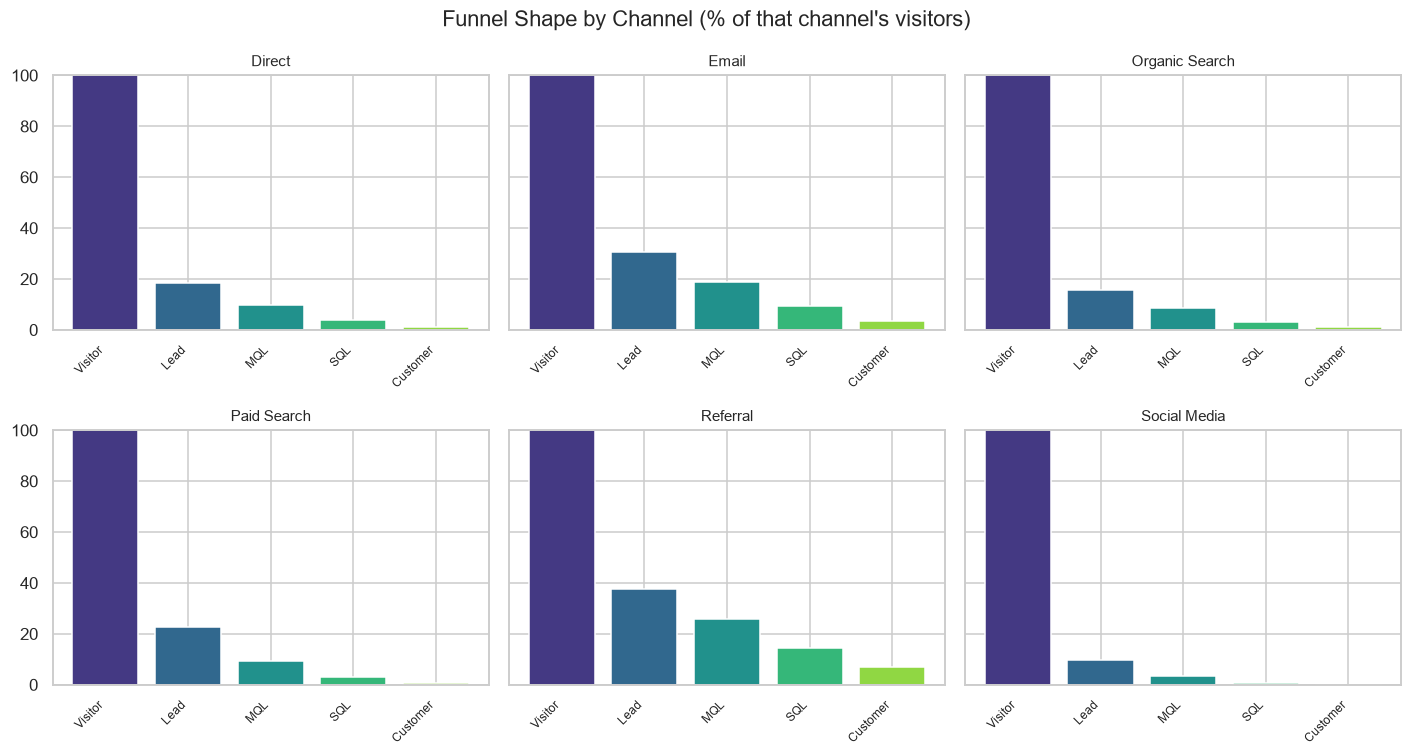

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, (ch, g) in zip(axes.flat, df.groupby("channel")):
    counts = pd.Series({s: (g["stage_rank"] >= i).sum() for s, i in stage_rank.items()})
    pct = counts / counts.iloc[0] * 100
    ax.bar(STAGES, pct, color=sns.color_palette("viridis", len(STAGES)))
    ax.set_title(ch, fontsize=10)
    ax.set_xticks(range(len(STAGES)))
    ax.set_xticklabels(STAGES, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 100)
fig.suptitle("Funnel Shape by Channel (% of that channel's visitors)")
plt.tight_layout()
plt.show()


## 6. Interactive Demo (for screen recording)

Run this cell in a **live** Jupyter session (classic Notebook, JupyterLab, or Colab — not a static
export). Use the channel dropdown like a Power BI slicer: pick a channel and watch the funnel chart
and headline stats update. This is the cell to screen-record for a LinkedIn demo video.


In [12]:
from ipywidgets import interact

def show_funnel(channel="All"):
    data = df if channel == "All" else df[df["channel"] == channel]
    counts = pd.Series({s: (data["stage_rank"] >= i).sum() for s, i in stage_rank.items()})
    pct = counts / counts.iloc[0] * 100 if counts.iloc[0] else counts * 0

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(STAGES, counts.values, color=sns.color_palette("Blues_r", len(STAGES)))
    for b, v, p in zip(bars, counts.values, pct.values):
        ax.text(b.get_x() + b.get_width()/2, v + max(counts.values)*0.02 if max(counts.values) else 1,
                f"{v:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Funnel — {channel}")
    ax.set_ylabel("Users (cumulative)")
    plt.tight_layout()
    plt.show()

    overall_conv = counts.iloc[-1] / counts.iloc[0] * 100 if counts.iloc[0] else 0
    print(f"Visitors: {counts.iloc[0]:,}  |  Customers: {counts.iloc[-1]:,}  |  Overall conversion: {overall_conv:.2f}%")

channel_options = ["All"] + sorted(df["channel"].unique().tolist())
interact(show_funnel, channel=channel_options);


interactive(children=(Dropdown(description='channel', options=('All', 'Direct', 'Email', 'Organic Search', 'Pa…

## 7. Key Insights

1. **Biggest overall drop-off is Visitor → Lead (only 19.7% convert).** This is a top-of-funnel
   / landing-page / offer problem, not a sales problem — most people never even engage.
2. **Social Media has the weakest funnel at every stage** despite being the 2nd-largest traffic
   source, and it's the only channel losing money on spend (0.1x ROI).
3. **Referral and Email are the highest-quality channels** — smaller volume, but 5–10x better
   lead-to-customer conversion and by far the best ROI (53x and 20x).
4. **Paid Search brings good lead *volume*** (22.7% visitor→lead, the highest) **but leads are
   low quality** — only 3.5% of its leads become customers, and it's roughly break-even on spend.
5. **SQL → Customer conversion (37%) lags** the earlier MQL → SQL step (41%), suggesting a
   closing/sales-process issue on qualified leads, not just a lead-quality issue.
6. **Conversion rate improved through the analyzed period** (0.8% in Jan to 2.8% in Jun),
   consistent with channel mix shifting toward higher-quality sources over time.

## 7. Recommendations

- **Fix the Visitor → Lead step first** — it's the largest leak by volume. A/B test landing
  page offers, reduce lead-form friction, and add clearer CTAs before spending more on traffic.
- **Cut or rework Social Media spend.** At 0.1x ROI it's actively losing money; either redesign
  the offer/targeting or reallocate that budget to Referral and Email.
- **Double down on Referral and Email** — build a formal referral incentive program and expand
  email nurture sequences; they're already outperforming every paid channel by 3–10x on ROI.
- **Audit Paid Search targeting/keywords.** High lead volume but low lead-to-customer conversion
  usually means broad or misaligned keyword targeting pulling in low-intent clicks.
- **Investigate the sales process for SQL → Customer.** Since MQL → SQL holds up reasonably well,
  the drop after that points to follow-up speed, pricing objections, or proposal quality rather
  than lead quality.
